In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/elakiricoder/gender-classification-dataset/gender_classification_v7.csv')
df

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


In [2]:
df.describe()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
count,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000,5001.000000
mean,0.869626,13.181484,5.946311,0.493901,0.507898,0.493101,0.498900
std,0.336748,1.107128,0.541268,0.500013,0.499988,0.500002,0.500049
min,0.000000,11.400000,5.100000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,12.200000,5.500000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,13.100000,5.900000,0.000000,1.000000,0.000000,0.000000
75%,1.000000,14.000000,6.400000,1.000000,1.000000,1.000000,1.000000
max,1.000000,15.500000,7.100000,1.000000,1.000000,1.000000,1.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [4]:
df.isnull().sum()

long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64

In [5]:
df.nunique()

long_hair                     2
forehead_width_cm            42
forehead_height_cm           21
nose_wide                     2
nose_long                     2
lips_thin                     2
distance_nose_to_lip_long     2
gender                        2
dtype: int64

In [6]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [7]:
df['gender'].value_counts()

gender
Female    2501
Male      2500
Name: count, dtype: int64

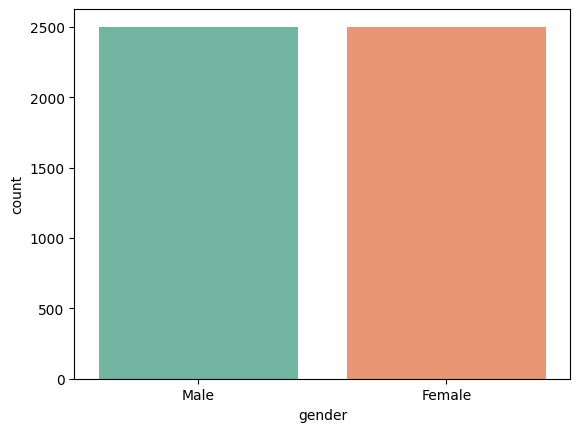

In [8]:
sns.countplot(x='gender', data=df, hue='gender',palette='Set2')
plt.show()

In [9]:
df_nb = pd.read_csv('/kaggle/input/datasets/elakiricoder/gender-classification-dataset/gender_classification_v7.csv')
df_nb

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


In [10]:
df_nb['gender'] = df['gender'].map({'Male':1, 'Female':0})

In [11]:
df_nb

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,1
1,0,14.0,5.4,0,0,1,0,0
2,0,11.8,6.3,1,1,1,1,1
3,0,14.4,6.1,0,1,1,1,1
4,1,13.5,5.9,0,0,0,0,0
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,0
4997,1,11.9,5.4,0,0,0,0,0
4998,1,12.9,5.7,0,0,0,0,0
4999,1,13.2,6.2,0,0,0,0,0


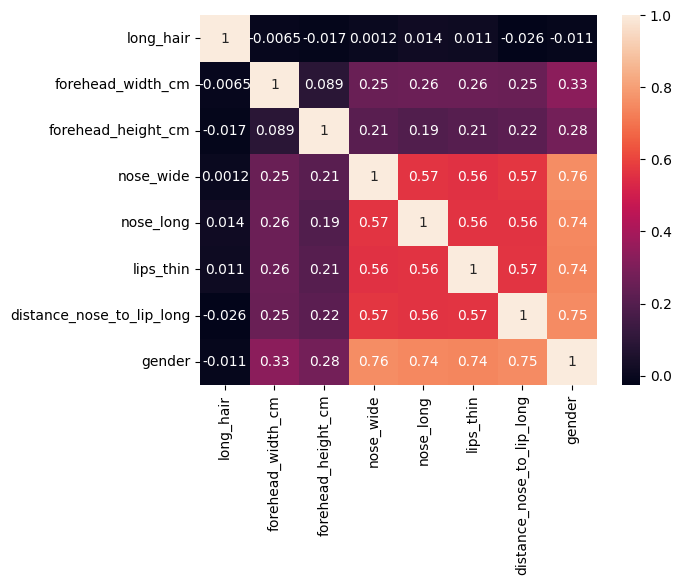

In [12]:
sns.heatmap(df_nb.corr(), annot=True)
plt.show()

# **Feature Selection**

In [13]:
x_data = df_nb.drop(['gender'],axis=1)
y_data = df_nb['gender'].values

# **Train-Test Split**

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=1)

# **Gaussian Naive Bayes**

In [15]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(x_train, y_train)

print('Train Accuracy nya adalah: ', gnb.score(x_train, y_train))
print('Test Accuracy nya adalah: ', gnb.score(x_test, y_test))

Train Accuracy nya adalah:  0.97
Test Accuracy nya adalah:  0.9713524317121919


# **Multinomial Naive Bayes**

In [16]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()

mnb.fit(x_train, y_train)

print('Train Accuracy nya adalah: ', mnb.score(x_train, y_train))
print('Test Accuracy nya adalah: ', mnb.score(x_test, y_test))

Train Accuracy nya adalah:  0.9565714285714285
Test Accuracy nya adalah:  0.960692871419054


# **Bernoulli Naive Bayes**

In [17]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()

bnb.fit(x_train, y_train)

print('Train Accuracy nya adalah: ', bnb.score(x_train, y_train))
print('Test Accuracy nya adalah: ', bnb.score(x_test, y_test))

Train Accuracy nya adalah:  0.9585714285714285
Test Accuracy nya adalah:  0.9640239840106596


In [18]:
from sklearn.svm import SVC

svm_model = SVC()

svm_model.fit(x_train, y_train)

print('Train Accuracy nya adalah: ', svm_model.score(x_train, y_train))
print('Test Accuracy nya adalah: ', svm_model.score(x_test, y_test))

Train Accuracy nya adalah:  0.9697142857142858
Test Accuracy nya adalah:  0.966688874083944
